In [1]:
import logging

import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-40s :: %(message)s'
)


## Inverse obstacle problem with Dirichlet boundary condition

We consider the operator that maps the shape of a sound-soft obstacle $D$ to the far-field measurements. 
The scattering problem is described by

$$
        \begin{cases}
            \Delta u +\kappa^2 u = 0 & \text{ in } \mathbb{R}^2\backslash\overline{D}\\
             u = 0  & \text{ on } \partial D\\
            \displaystyle{\lim_{r\to\infty}}r^{\frac{1}{2}}(\frac{\partial u^s}{\partial r}-i\kappa u^s)=0 & \text{ for } r=|x|,
        \end{cases}
$$
where $u=u^s+u^i$ is the total field generated by a plane incident wave $u^i(x)=\exp(i\kappa x\cdot d)$ in direction 
$d\in S^1$, 
and $D$ is a bounded obstacle in $\mathbb{R}^2$ with $\partial D\in\mathcal{C}^2$.
The far field pattern $u^{\infty}$ of the scattered field $u^s$ is defined by the asymptotic relation
$$
u^s(x) = \frac{e^{i\kappa|x|}}{\sqrt{|x}} u^{\infty}\left(\frac{x}{|x|}\right)\left(1+O\left(\frac{1}{|x|}\right)\right),\qquad 
|x|\to \infty.
$$ 
The forward operator maps a parameterization of $\partial D$ to a complex matrix, the columns of which are far field patterns 
corresponding to incident waves from different directions.      

In [2]:
from  dirichlet_op import DirichletOp
"""
op = DirichletOp(
    kappa = 8,
    N_inc=4,
    N_meas=64,
    N_ieq=64
)"""

'\nop = DirichletOp(\n    kappa = 8,\n    N_inc=4,\n    N_meas=64,\n    N_ieq=64\n)'

### Neumann boundary condition
Instead of the Dirichlet condition $u=0$ on $\partial D$, we can also consider a Neumann condition for the total field, 
corresponding to sound-hard obstacles:
$$
\frac{\partial u}{\partial \nu}=0\qquad \text{on }\partial D. 
$$

In [3]:
from neumann_op import NeumannOp
op = NeumannOp(
    kappa = 4,
    N_inc=4,
    N_meas=64,
    N_ieq=64
)

### Transmission conditions 
Scattering by a homogeneous penetrable obstacle can be described by transmission conditions: 
$$
        \begin{cases}
            \Delta u^{int} +\kappa_i^2 u^{int} = 0 & \text{ in } D \\
            \Delta u^{s} +\kappa_e^2 u^{s} = 0 & \text{ in } \mathbb{R}^2\backslash\overline{D}\\
             u^{int}=u & \text{ on } \partial D\\
            \frac{\partial u^{int}}{\partial\nu}=\rho\frac{\partial u}{\partial\nu} & \text{ on }\partial D\\
            \displaystyle{\lim_{r\to\infty}}r^{\frac{1}{2}}(\frac{\partial u^s}{\partial r}-i\kappa u^s)=0 &\text{ for } r=|x|.
        \end{cases}
$$
Here $\rho\in\mathbb{C}\backslash 0$, and $u=u^{s}+u^{i}$ is the total field in $\mathbb{R}^2\backslash\overline{D}$.


In [4]:
from transmission_op import TransmissionOp
op = TransmissionOp(
    kappa_in = 2,
    kappa_ex = 4,
    N_inc=4,
    N_meas=64,
    N_ieq=64
)

In [5]:
from regpy.solvers import Setting
from regpy.hilbert import L2, Sobolev
from regpy.vecsps.curve import apple

setting = Setting(op=op, penalty=Sobolev, data_fid=L2)

# compute exact synthtic data
farfield, exact_solution = op.create_synthetic_data(apple,N_ieq_synth=64)

# add Gaussian noise to exact data
noise_level = 0.01
noise = op.codomain.randn()
noise = noise_level*setting.h_codomain.norm(farfield)/setting.h_codomain.norm(noise)*noise
data = farfield+noise

#Initial guess
t = 2*np.pi*np.arange(0, op.N_FK)/op.N_FK
init = 0.45*np.append(np.cos(t), np.sin(t)).reshape((2, op.N_FK))
init=init.flatten()

2025-12-17 17:03:20,292 WARNING Setting                                  :: Setting does not contain any explicit data.


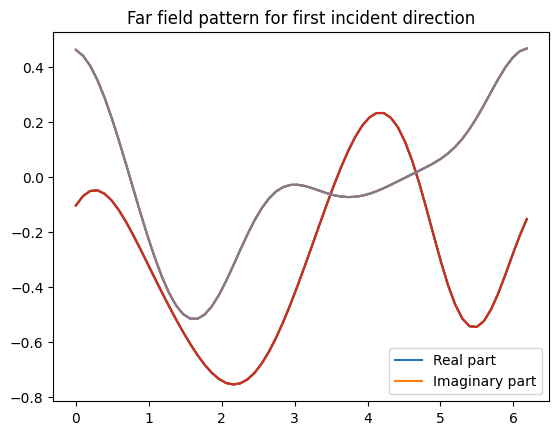

In [6]:
x= op.codomain.coords[0]
y = farfield[:,0]
ax = plt.plot(x,y.real,x,y.imag)
plt.title('Far field pattern for first incident direction')
xlabel = 'Measurement direction (rad)'
plt.legend(['Real part','Imaginary part'])

2025-12-17 17:03:22,359 INFO CombineRules                             :: it. 0>=10 | rel. discrep. = 216.42< 2.10
2025-12-17 17:03:22,359 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2025-12-17 17:03:23,045 INFO CombineRules                             :: it. 1>=10 | rel. discrep. = 54.49< 2.10
2025-12-17 17:03:23,050 INFO NewtonCG                                 :: Inner CG iteration required 1 steps.
2025-12-17 17:03:23,609 INFO CombineRules                             :: it. 2>=10 | rel. discrep. = 27.69< 2.10
2025-12-17 17:03:23,623 INFO NewtonCG                                 :: Inner CG iteration required 2 steps.
2025-12-17 17:03:24,077 INFO CombineRules                             :: it. 3>=10 | rel. discrep. = 15.32< 2.10
2025-12-17 17:03:24,092 INFO NewtonCG                                 :: Inner CG iteration required 3 steps.
2025-12-17 17:03:24,733 INFO CombineRules                             :: it. 4>=10 | rel. discrep. = 9.23< 

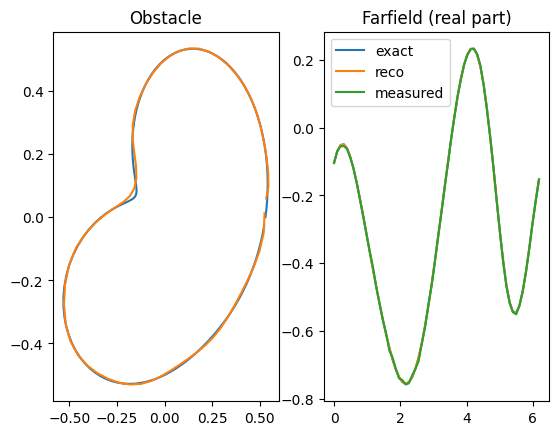

In [8]:
from regpy.solvers.nonlinear.irgnm import IrgnmCG
from regpy.solvers.nonlinear.newton import NewtonCG
import regpy.stoprules as rules

#Solver: NewtonCG or IrgnmCG
solver = NewtonCG(
    setting, data, init = init,
        cgmaxit=50, rho=0.6
)

"""
solver = IrgnmCG(
    setting, data,
    regpar=1.,
    regpar_step=0.5,
    init=init
)
"""
stoprule = (
    rules.CountIterations(10) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=noise_level,
        tau=2.1
    )
)

#Plot function
fig, axs = plt.subplots(1, 2)
axs[0].set_title('Obstacle')
axs[1].set_title('Farfield (real part)')

reco, reco_data = solver.run(stoprule)
axs[0].plot(*exact_solution.z)
axs[0].plot(*op.domain.bd_eval(reco, nvals=op.N_ieq, nderivs=3).z)

axs[1].plot(op.codomain.coords[0][:,0], farfield.real[:,0], label='exact')
axs[1].plot(op.codomain.coords[0][:,0], reco_data.real[:,0], label='reco')
axs[1].plot(op.codomain.coords[0][:,0], data.real[:,0], label='measured')
axs[1].legend()
plt.show()